In [5]:
import os
import librosa
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

def split_audio_into_seconds(audio_file, segment_duration=1, output_folder="adult_lobsters"):
  """
  Splits an audio file into 1-second segments and saves them to a specified folder.

  Args:
    audio_file: Path to the audio file.
    segment_duration: Duration of each segment in seconds (default: 1 second).
    output_folder: Path to the output folder where segments will be saved. 

  Returns:
    None
  """

  # Create the output folder if it doesn't exist
  os.makedirs(output_folder, exist_ok=True) 

  y, sr = librosa.load(audio_file)
  samples_per_segment = int(sr * segment_duration)

  for i in range(0, len(y), samples_per_segment):
    segment = y[i:i + samples_per_segment]
    if len(segment) < samples_per_segment:
      # Pad the last segment with zeros to ensure consistent length
      segment = np.pad(segment, (0, samples_per_segment - len(segment)), 'constant') 
    segment_filename = os.path.join(output_folder, f"segment_{i // samples_per_segment}.wav") 
    sf.write(segment_filename, segment, sr)

# Example usage:
audio_file_path = "female_lobsters.wav" 
output_directory = "female_losbters"  # Create a folder named "audio_segments"
split_audio_into_seconds(audio_file_path, output_folder=output_directory)

22050
22050


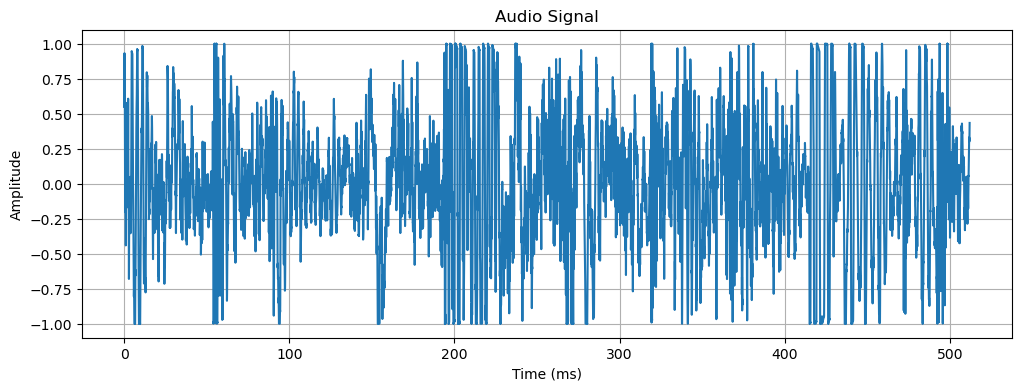

In [10]:
import librosa
import matplotlib.pyplot as plt

# Load the audio file
y1, sr1 = librosa.load('female_losbters/segment_1.wav') 

# y: Audio time series (numpy array)
# sr: Sampling rate (in Hz)

print(len(y1)) 
print(sr1) 
# Create time array
t1 = librosa.times_like(y1) 

# Plot the audio signal
plt.figure(figsize=(12, 4))
plt.plot(t1, y1)
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.title('Audio Signal')
plt.grid(True)
plt.show()

In [8]:
#Alll features for table creation

import os
import librosa
import numpy as np
from scipy.stats import kurtosis

def analyze_audio_folder_average(audio_folder):
    """
    Analyzes all audio files in a folder and computes the *average* of features 
    across all files.

    Args:
        audio_folder: The path to the folder containing the audio files.

    Returns:
        A dictionary of average features, or None if the folder doesn't exist 
        or if there is an issue with the audio files.
    """

    if not os.path.exists(audio_folder) or not os.path.isdir(audio_folder):
        print(f"Error: Folder '{audio_folder}' not found.")
        return None

    all_data = []  # List to store all audio data
    sr_list = [] # List to store sample rates
    for filename in os.listdir(audio_folder):
        if filename.endswith(('.wav', '.mp3', '.flac')):
            filepath = os.path.join(audio_folder, filename)
            try:
                y, sr = librosa.load(filepath)  # Load audio
                all_data.append(y)
                sr_list.append(sr)
            except Exception as e:
                print(f"Error processing file '{filename}': {e}")
                return None  # Or handle differently

    if not all_data:
        print(f"No valid audio files found in '{audio_folder}'.")
        return None

    # Ensure all sample rates are equal. If not, you may need to resample.
    if not all(sr == sr_list[0] for sr in sr_list):
        print("Warning: Sample rates are not equal across all files. Averaging may not be accurate. Consider resampling.")
        # If necessary, resample all audio to a common sample rate
        common_sr = max(sr_list) # Example: use the max sample rate as the common rate
        resampled_data = []
        for y, sr in zip(all_data, sr_list):
            if sr != common_sr:
                y_resampled = librosa.resample(y, sr, common_sr)
                resampled_data.append(y_resampled)
            else:
                resampled_data.append(y)

        all_data = resampled_data # Use resampled data for further processing
        sr = common_sr
    else:
        sr = sr_list[0] # Use the first sample rate as the common one

    all_data = np.concatenate(all_data)  # Combine all audio data into one array


    # Feature computation (now on the combined data)
    mean = np.mean(all_data)
    kurt = kurtosis(all_data)
    energy = np.sum(all_data**2)
    rms = np.sqrt(np.mean(all_data**2))
    zcr = librosa.feature.zero_crossing_rate(all_data).mean()
    spectral_centroid = librosa.feature.spectral_centroid(y=all_data, sr=sr).mean()
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=all_data, sr=sr).mean()
    rolloff = librosa.feature.spectral_rolloff(y=all_data, sr=sr).mean()
    mfccs = librosa.feature.mfcc(y=all_data, sr=sr).mean(axis=1)

    average_features = {
        "mean": mean,
        "kurtosis": kurt,
        "energy": energy,
        "rms": rms,
        "zcr": zcr,
        "spectral_centroid": spectral_centroid,
        "spectral_bandwidth": spectral_bandwidth,
        "rolloff": rolloff,
        "mfcc_1": mfccs[0],
        "mfcc_2": mfccs[1],
        # ... other MFCCs
        "mfcc_13": mfccs[12],
    }

    return average_features



# Example usage:
audio_folder = "juvenile_lobsters"  # Replace with the actual path

average_features = analyze_audio_folder_average(audio_folder)

if average_features:
    print("Average features across all files:")
    for feature_name, feature_value in average_features.items():
        print(f"  {feature_name}: {feature_value}")
else:
  print("An error occurred during audio analysis.")

Average features across all files:
  mean: 0.008454149588942528
  kurtosis: 0.2631309880252797
  energy: 11389645.0
  rms: 0.4639222323894501
  zcr: 0.04206916171330786
  spectral_centroid: 1108.14148824982
  spectral_bandwidth: 1497.004988132402
  rolloff: 2044.1871182468285
  mfcc_1: -58.79509353637695
  mfcc_2: 162.82376098632812
  mfcc_13: 1.2067254781723022


          mean  kurtosis        energy       rms   zcr  spectral_centroid  \
0     0.007802  0.513191    161.737640  0.085645  1128        1188.468368   
1     0.007347  1.011037   2737.204102  0.352330  1160        1129.480105   
2     0.006554  2.641924   2301.828125  0.323096  1514        1393.189142   
3     0.008175  3.300901   1643.910645  0.273045  1387        1261.116370   
4     0.006448 -1.160957   8876.716797  0.634486   658         896.354034   
...        ...       ...           ...       ...   ...                ...   
4495  0.009112  2.409983   3134.206543  0.377016  1281        1556.666655   
4496  0.008542 -0.144625   5321.323242  0.491253  1148        1260.647349   
4497  0.007574  3.476348    105.935776  0.069313  1413        1488.298757   
4498  0.007916  2.689085   1435.535400  0.255154  1177        1145.095753   
4499  0.005262 -1.312936  10601.626953  0.693397  1195        1460.167320   

      spectral_bandwidth      rolloff      mfcc_1      mfcc_2   mfcc_13  
0

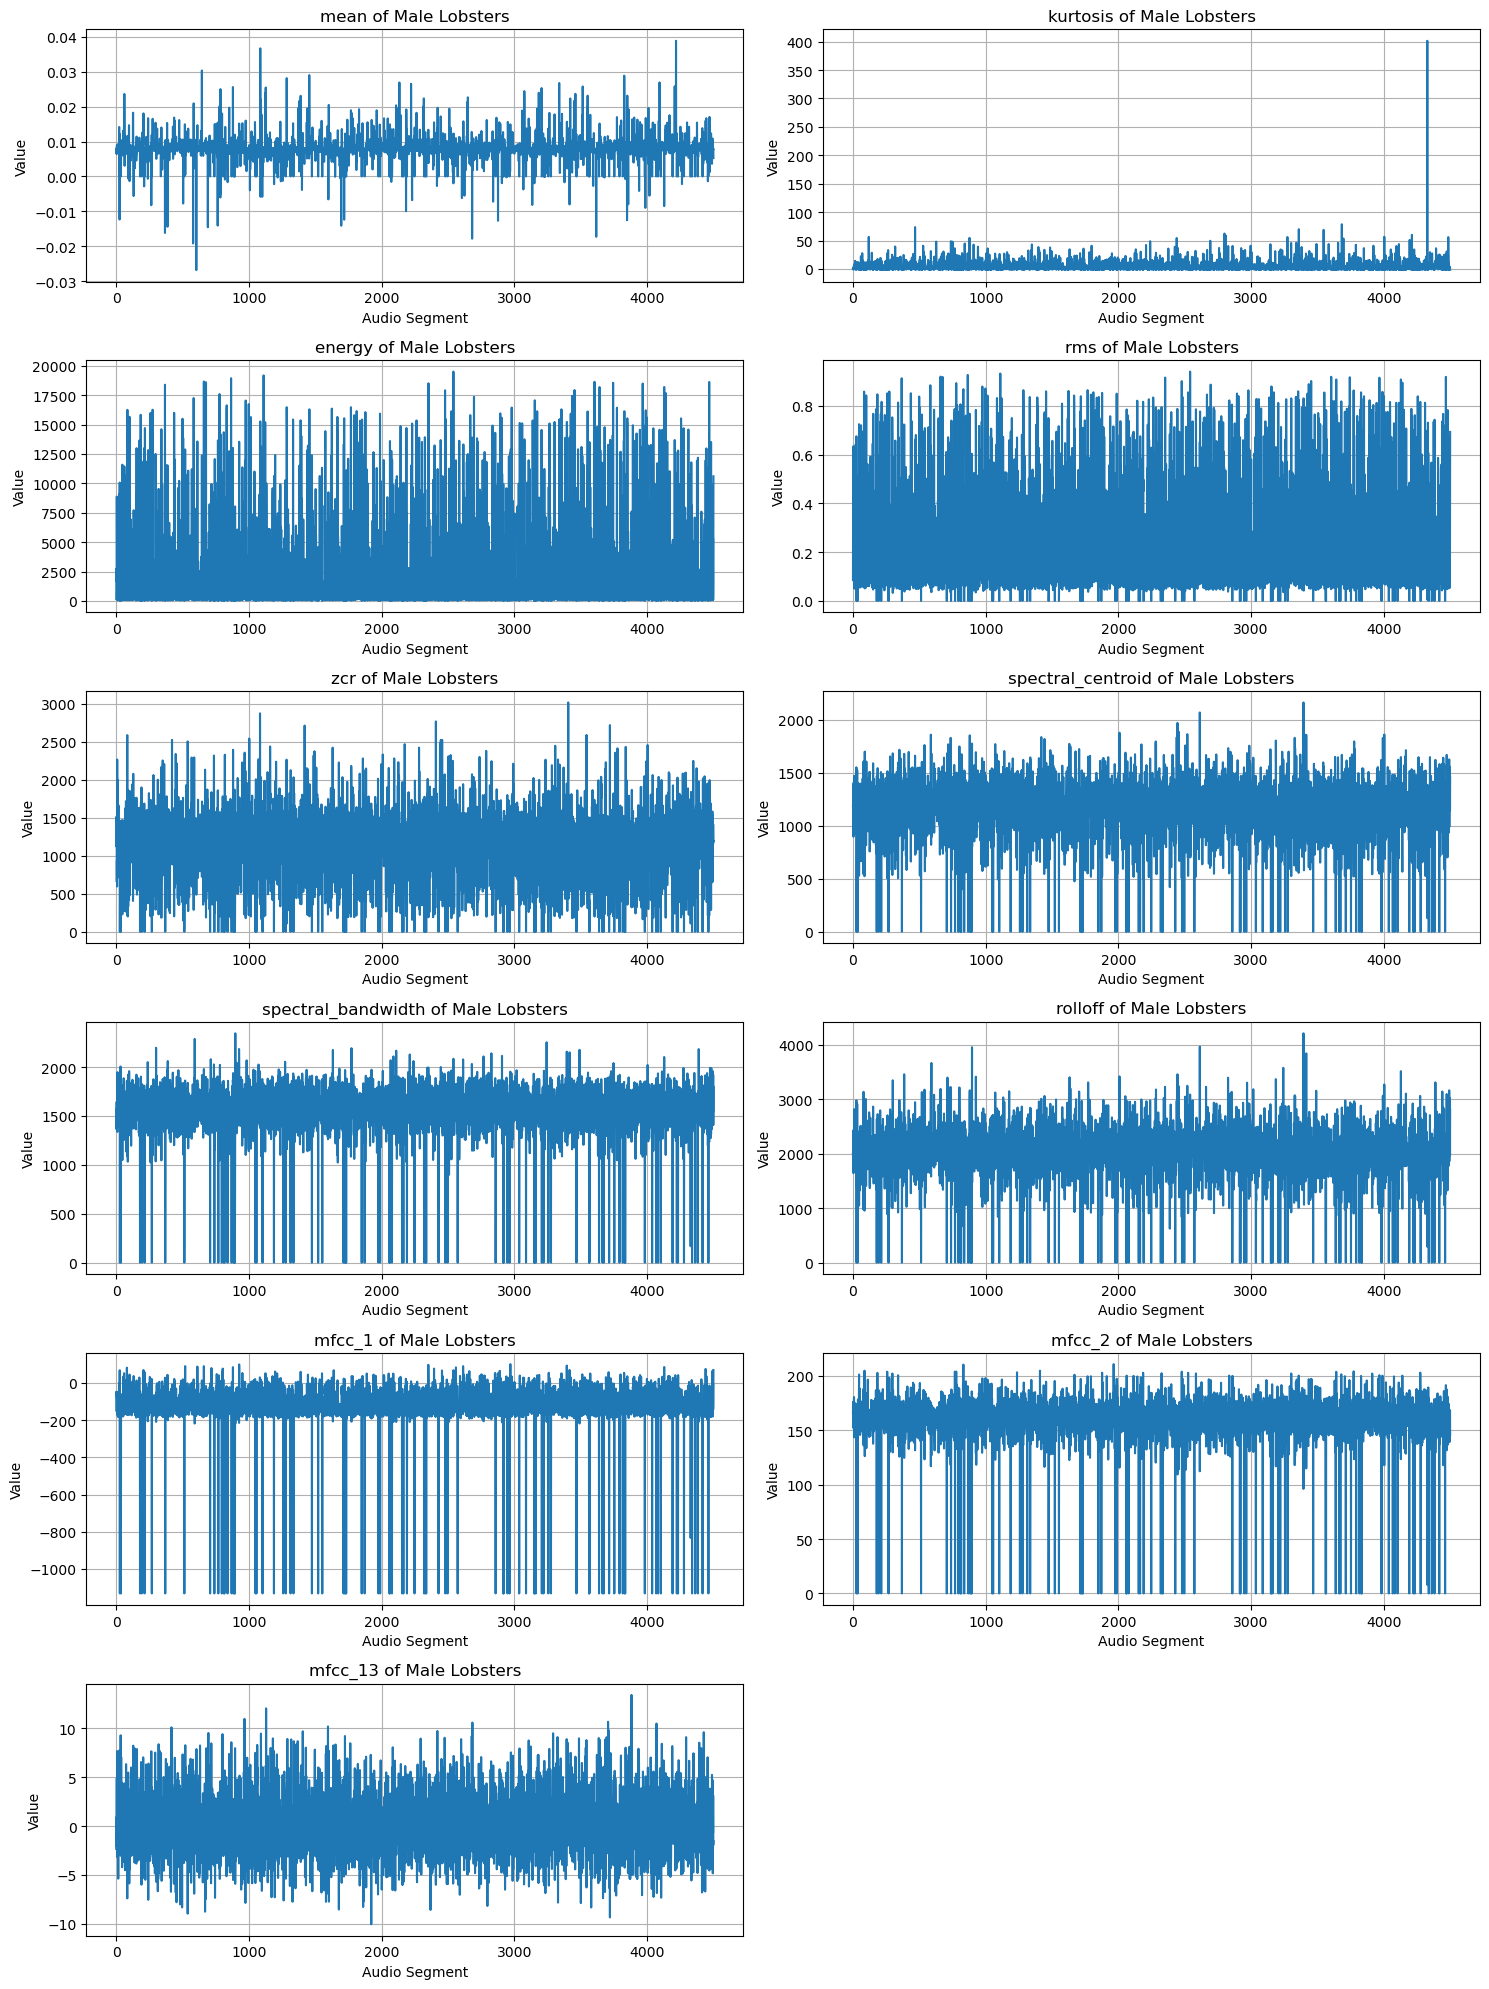

In [19]:

import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def extract_features(file_path):
    """Extracts audio features from a given file."""
    y, sr = librosa.load(file_path)  # Load audio
    
    # Calculate features
    mean = np.mean(y)
    kurtosis = pd.Series(y).kurt() # Kurtosis needs a pandas Series
    energy = np.sum(y**2)
    rms = np.sqrt(np.mean(y**2))
    zcr = librosa.zero_crossings(y).sum()
    spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13) # Calculate 13 MFCCs
    mfcc_1 = np.mean(mfccs[0])
    mfcc_2 = np.mean(mfccs[1])
    mfcc_13 = np.mean(mfccs[12])  # Access the 13th MFCC (index 12)

    return {
        'mean': mean,
        'kurtosis': kurtosis,
        'energy': energy,
        'rms': rms,
        'zcr': zcr,
        'spectral_centroid': spectral_centroid,
        'spectral_bandwidth': spectral_bandwidth,
        'rolloff': rolloff,
        'mfcc_1': mfcc_1,
        'mfcc_2': mfcc_2,
        'mfcc_13': mfcc_13,
    }

def plot_features(features_df, filename):
    """Plots the extracted features."""
    num_segments = features_df.shape[0] # number of audio segments
    x_axis = range(num_segments) # create a list from 0 to number of segments

    plt.figure(figsize=(15, 20)) # Adjust figure size for better visualization

    feature_names = list(features_df.columns) # get the feature names dynamically
    for i, feature_name in enumerate(feature_names):
        plt.subplot(6, 2, i+1) # Subplots in a grid (adjust as needed)
        plt.plot(x_axis, features_df[feature_name], marker='', linestyle='-') # Plot each feature
        plt.title(feature_name +" of Male Lobsters")
        plt.xlabel("Audio Segment")
        plt.ylabel("Value")
        plt.grid(True)
    
    plt.tight_layout() # Adjust subplot params for a tight layout
    plt.savefig(f"{filename}.png")  # save the figure as png
    plt.show() # Show the plot


if __name__ == "__main__":
    folder_path = "male_lobsters"  # Replace with the actual path
    all_features = []

    for filename in os.listdir(folder_path):
        if filename.endswith((".wav", ".mp3", ".flac")):  # Add other extensions if needed
            file_path = os.path.join(folder_path, filename)
            features = extract_features(file_path)
            all_features.append(features)

    features_df = pd.DataFrame(all_features)
    print(features_df) # Print the DataFrame
    plot_features(features_df, "audio_features")  # Plot and save


22050


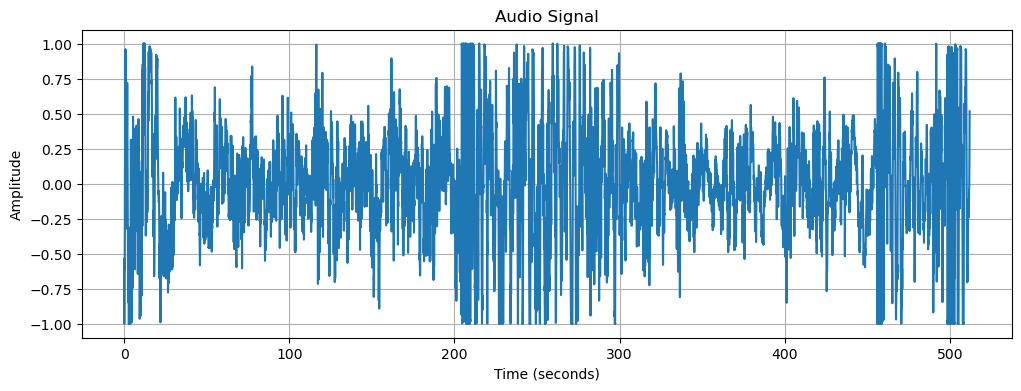

In [7]:
import librosa
import matplotlib.pyplot as plt

# Load the audio file
y2, sr2 = librosa.load('female_losbters/segment_0.wav') 

# y: Audio time series (numpy array)
# sr: Sampling rate (in Hz)

print(len(y2)) 
#print(sr2) 
# Create time array
t2 = librosa.times_like(y2) 

# Plot the audio signal
plt.figure(figsize=(12, 4))
plt.plot(t2, y2)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Audio Signal')
plt.grid(True)
plt.show()

Number of files in 'female_lobsters': 2900
Number of files in 'male_lobsters': 4409
Number of files in 'adult_lobsters': 4907
Number of files in 'juvenile_lobsters': 2400


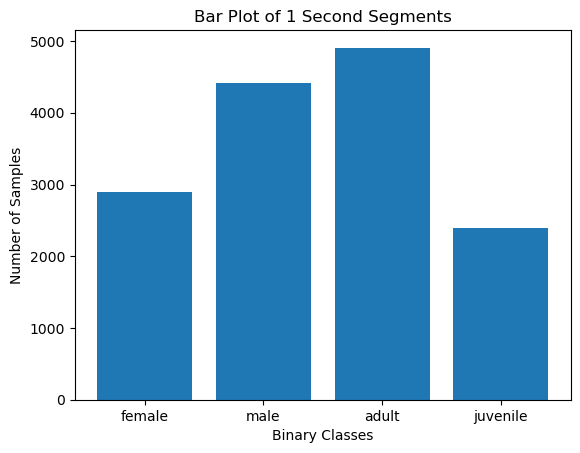

In [29]:
import os
import matplotlib.pyplot as plt


def count_files_in_directory(directory):
  """
  Counts the number of files within a given directory.

  Args:
    directory: The path to the directory.

  Returns:
    The number of files in the directory.
  """
  file_count = 0
  for root, dirs, files in os.walk(directory):
    file_count += len(files)
  return file_count

# Example usage:
directory_path2 = 'male_lobsters'
directory_path1 = 'female_lobsters'  # Replace with the actual directory path
directory_path3 = 'adult_lobsters'
directory_path4 = 'juvenile_lobsters'
num_files1 = count_files_in_directory(directory_path1)
num_files2 = count_files_in_directory(directory_path2)
num_files3 = count_files_in_directory(directory_path3)
num_files4 = count_files_in_directory(directory_path4)

print(f"Number of files in '{directory_path1}': {num_files1}")
print(f"Number of files in '{directory_path2}': {num_files2}")
print(f"Number of files in '{directory_path3}': {num_files3}")
print(f"Number of files in '{directory_path4}': {num_files4}")

# Data
x_labels = ["female", "male", "adult", "juvenile"]
y_values = [num_files1, num_files2, num_files3, num_files4]

# Create the bar plot
plt.bar(x_labels, y_values)

# Customize the plot
plt.xlabel("Binary Classes")
plt.ylabel("Number of Samples")
plt.title("Bar Plot of 1 Second Segments")

# Show the plot
plt.show()


In [9]:
 import os
import librosa
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score, f1_score
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import time
from tensorflow.keras.optimizers import Adam

# Define paths to the folders
folder1_path = 'adult_lobsters'  # Replace with the actual path to folder 1
folder2_path = 'juvenile_lobsters'  # Replace with the actual path to folder 2

# Define parameters
sample_rate = 22050
n_fft = 2048
hop_length = 512
num_classes = 2  # Binary classification

# Load audio data and create labels
def load_data(folder_path):
    X = []
    y = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".wav"):  # Assuming WAV files
            file_path = os.path.join(folder_path, filename)
            audio, _ = librosa.load(file_path, sr=sample_rate)
            mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
            X.append(mfccs.T)  # Transpose for Conv1D input
            y.append(1 if folder_path == folder1_path else 0)  # Label 1 for folder1, 0 for folder2
    return np.array(X), np.array(y)

# Load data for both folders
X1, y1 = load_data(folder1_path)
X2, y2 = load_data(folder2_path)

# Combine data from both folders
X = np.concatenate((X1, X2), axis=0)
y = np.concatenate((y1, y2), axis=0)

seed_value = 42
np.random.seed(seed_value)


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value)


# ... (Your code for loading data, preprocessing, etc.) ...

def create_1d_cnn_model(num_layers, input_shape, num_classes):
  """
  Creates a 1D CNN model with a variable number of layers.

  Args:
    num_layers: The number of convolutional layers in the model.
    input_shape: The shape of the input data (e.g., (timesteps, features)).
    num_classes: The number of output classes.

  Returns:
    The compiled 1D CNN model.
  """

  model = Sequential()

  # Add convolutional layers
  for _ in range(num_layers):
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))

  # Flatten the output
  model.add(Flatten())

  # Add fully connected layers
  model.add(Dense(128, activation='relu'))
  model.add(Dense(num_classes, activation='softmax'))

  # Compile the model
  model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])

  return model

# Example usage:
#input_shape = (100, 1)  # Replace with your actual input shape
input_shape = (None, 1, 32)
#kernel_shape = (3, 32, 32)
#dilation_rate = [1]
num_classes = 2  # Replace with the number of classes in your dataset

# Create models with varying number of layers
models = []
for i in range(1, 21):
  models.append(create_1d_cnn_model(i, input_shape, num_classes))

# Train and evaluate each model (replace with your training and evaluation code)
# ...


# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary() 

#Early Stopping
#early_stopping = EarlyStopping(monitor='val_accuracy', patience=5)

# Train the model
history = model.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_test, y_test))#, callbacks=[early_stopping])


# Evaluate the model
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_labels)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred_labels, average='weighted')
print("Precision:", precision)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)
print("Confusion Matrix:\n", cm)

recall = recall_score(y_test, y_pred_labels) 
print(f"Recall: {recall}") 

# Create an F1-Score metric instance
##f1_score = tf.keras.metrics.F1Score()
# Update the metric with the true and predicted labels
##f1_score.update_state(y_test, y_pred)
# Get the calculated F1-Score
##f1Score = f1_score.result()
##print(f"F1-Score: {f1Score}")
# Calculate F1-score for binary classification
f1_binary = f1_score(y_test, y_pred_labels) 
print(f"F1-score (binary): {f1_binary}")

###mAP50 Begins here

# Example of a custom mAP@0.5 metric (simplified)
class MAP50(tf.keras.metrics.Metric):
    def __init__(self, name='map50', **kwargs):
        super(MAP50, self).__init__(name=name, **kwargs)
        self.map50 = self.add_weight(name='map50', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Implement your logic here to calculate mAP@0.5 
        # based on y_true and y_pred 
        # This will likely involve:
        # 1. Calculating Intersection over Union (IoU) for each prediction.
        # 2. Filtering predictions with IoU >= 0.5 (for mAP@0.5).
        # 3. Calculating precision and recall for each class.
        # 4. Calculating Average Precision (AP) for each class.
        # 5. Calculating Mean Average Precision (mAP) across all classes.

        # Placeholder: Replace with your actual mAP@0.5 calculation
        self.map50.assign(0.75)  # Example value, replace with actual calculation

    def result(self):
        return self.map50

# Create an instance of the custom mAP@0.5 metric
map50_metric = MAP50()

# Update the metric with your test data
map50_metric.update_state(y_test, y_pred_labels) 

# Get the calculated mAP@0.5
map50_value = map50_metric.result().numpy() 

print(f"mAP@0.5: {map50_value}")
#mAP50 ends here


def measure_inference_time(model, input_data, num_runs=100):
  """
  Measures the average inference time of a given model.

  Args:
    model: The trained model to be evaluated.
    input_data: A sample input for the model.
    num_runs: The number of times to run inference for averaging.

  Returns:
    The average inference time in seconds.
  """

  total_time = 0.0

  for _ in range(num_runs):
    start_time = time.time()
    _ = model(input_data)  # Run inference
    end_time = time.time()
    total_time += end_time - start_time

  average_time = total_time / num_runs

  return average_time

# Example Usage:
# Assuming you have a trained model (e.g., 'model') and some sample input data ('input_data')
input_data = X_test
average_inference_time = measure_inference_time(model, input_data) 
print(f"Average Inference Time: {average_inference_time:.6f} seconds") 


# Extract training and validation accuracy from history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Create an array of epochs
epochs = range(1, len(train_acc) + 1)

# Plot the accuracy
plt.plot(epochs, train_acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show() 

ValueError: Kernel shape must have the same length as input, but received kernel of shape (3, 32, 32) and input of shape (None, None, 1, 32).

In [39]:
import os
import librosa
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix


# Define paths to the folders
folder1_path = 'female_lobsters'  # Replace with the actual path to folder 1
folder2_path = 'male_lobsters'  # Replace with the actual path to folder 2

# Define parameters
sample_rate = 22050
n_fft = 2048
hop_length = 512
num_classes = 2  # Binary classification

# Load audio data and create labels
def load_data(folder_path):
    X = []
    y = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".wav"):  # Assuming WAV files
            file_path = os.path.join(folder_path, filename)
            audio, _ = librosa.load(file_path, sr=sample_rate)
            mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
            X.append(mfccs.T)  # Transpose for Conv1D input
            y.append(1 if folder_path == folder1_path else 0)  # Label 1 for folder1, 0 for folder2
    return np.array(X), np.array(y)

# Load data for both folders
X1, y1 = load_data(folder1_path)
X2, y2 = load_data(folder2_path)

# Combine data from both folders
X = np.concatenate((X1, X2), axis=0)
y = np.concatenate((y1, y2), axis=0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create 1D CNN model
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary() 

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_labels)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred_labels, average='weighted')
print("Precision:", precision)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)
print("Confusion Matrix:\n", cm)

/home/feliciano/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_22 (Conv1D)              │ (None, 42, 32)         │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 21, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 19, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,274 (321.38 KB)

 Trainable params: 82,274 (321.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6665 - loss: 2.3284 - val_accuracy: 0.7932 - val_loss: 0.4862
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8122 - loss: 0.4721 - val_accuracy: 0.8331 - val_loss: 0.3782
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8534 - loss: 0.3389 - val_accuracy: 0.8784 - val_loss: 0.2929
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8855 - loss: 0.2728 - val_accuracy: 0.8770 - val_loss: 0.2866
Epoch 5/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9112 - loss: 0.2121 - val_accuracy: 0.8473 - val_loss: 0.3582
Epoch 6/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9224 - loss: 0.1903 - val_accuracy: 0.9054 - val_loss: 0.2374
Epoch 7/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9297 - loss: 0.1650 - val_accuracy: 0.8905 - val_loss: 0.2559
Epoch 8/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9468 - loss: 0.1388 - val_accuracy: 0.

              mean     kurtosis        energy          rms          zcr  \
count  4407.000000  4407.000000   4407.000000  4407.000000  4407.000000   
mean      0.008036     4.729525   2391.906738     0.252555     0.051270   
std       0.003146     9.808811   3677.888916     0.211430     0.018475   
min      -0.026788    -1.954843      0.576052     0.005111     0.003584   
25%       0.007615     0.360376    152.082153     0.083049     0.040716   
50%       0.007813     1.898722    657.191711     0.172640     0.053977   
75%       0.008155     5.872616   2940.207520     0.365161     0.062544   
max       0.038811   401.326895  19505.132812     0.940525     0.132058   

       spectral_centroid  spectral_bandwidth      rolloff       mfcc_1  \
count        4407.000000         4407.000000  4407.000000  4407.000000   
mean         1194.197452         1587.151063  2067.041527  -115.473480   
std           229.278160          182.222659   389.837051    58.811440   
min           128.235638    

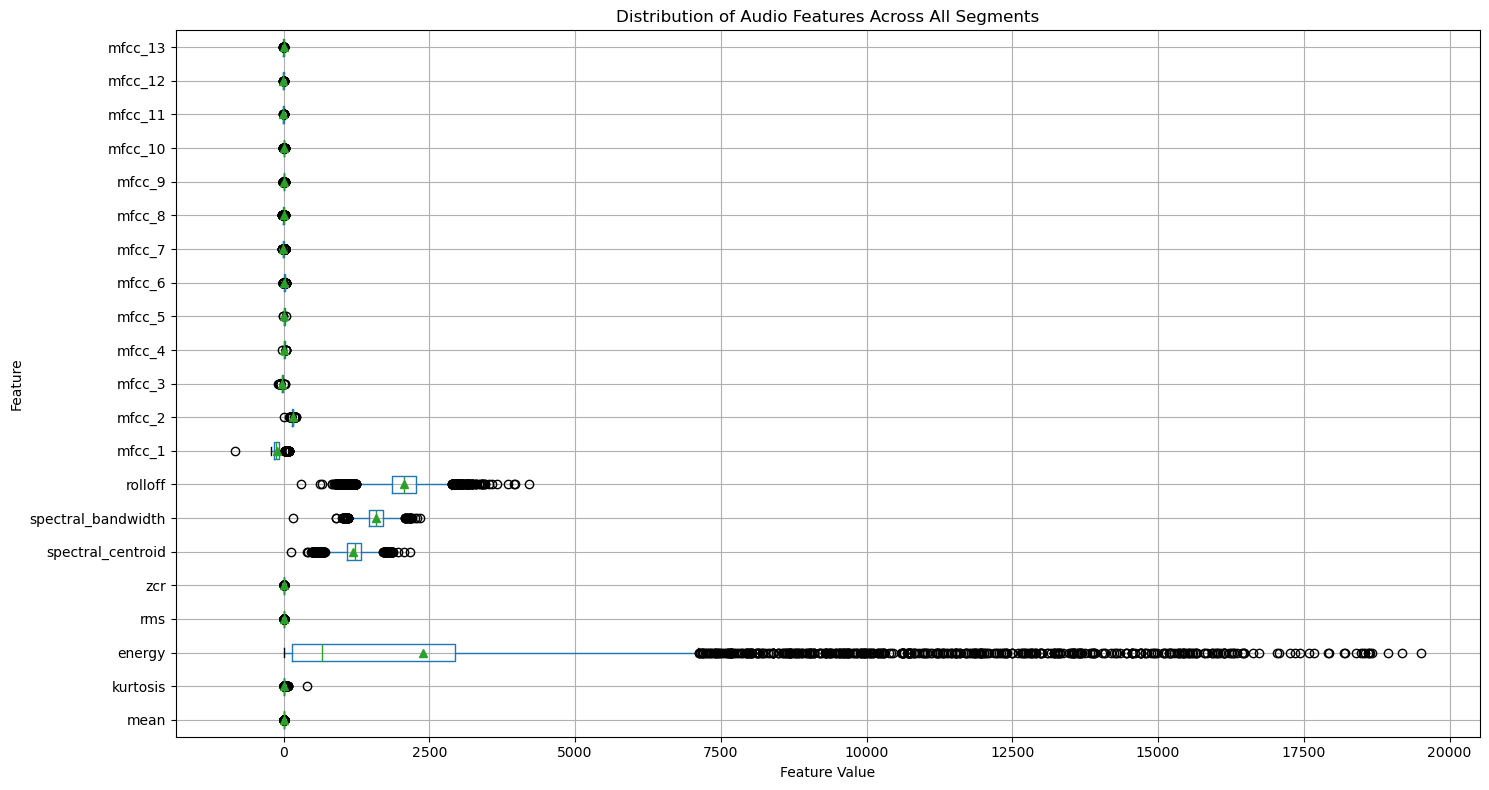

In [28]:
import os
import librosa
import numpy as np
from scipy.stats import kurtosis
import matplotlib.pyplot as plt
import pandas as pd  # For creating DataFrames for boxplots

def analyze_audio_folder(audio_folder):
    """Analyzes audio files, calculates features, and returns them in a DataFrame."""

    if not os.path.exists(audio_folder) or not os.path.isdir(audio_folder):
        print(f"Error: Folder '{audio_folder}' not found.")
        return None

    all_features = []

    for filename in os.listdir(audio_folder):
        if filename.endswith(('.wav',)):
            filepath = os.path.join(audio_folder, filename)
            try:
                y, sr = librosa.load(filepath, duration=1)  # Load only 1 second

                if len(y) != sr:
                    print(f"Warning: Audio file {filename} is not exactly 1 second long. Skipping.")
                    continue

                mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

                features = {
                    "mean": np.mean(y),
                    "kurtosis": kurtosis(y),
                    "energy": np.sum(y**2),
                    "rms": np.sqrt(np.mean(y**2)),
                    "zcr": librosa.feature.zero_crossing_rate(y).mean(),
                    "spectral_centroid": librosa.feature.spectral_centroid(y=y, sr=sr).mean(),
                    "spectral_bandwidth": librosa.feature.spectral_bandwidth(y=y, sr=sr).mean(),
                    "rolloff": librosa.feature.spectral_rolloff(y=y, sr=sr).mean(),
                    "mfcc_1": mfccs[0].mean(),
                    "mfcc_2": mfccs[1].mean(),
                    "mfcc_3": mfccs[2].mean(),
                    "mfcc_4": mfccs[3].mean(),
                    "mfcc_5": mfccs[4].mean(),
                    "mfcc_6": mfccs[5].mean(),
                    "mfcc_7": mfccs[6].mean(),
                    "mfcc_8": mfccs[7].mean(),
                    "mfcc_9": mfccs[8].mean(),
                    "mfcc_10": mfccs[9].mean(),
                    "mfcc_11": mfccs[10].mean(),
                    "mfcc_12": mfccs[11].mean(),
                    "mfcc_13": mfccs[12].mean(),
                }
                all_features.append(features)

            except Exception as e:
                print(f"Error processing file '{filename}': {e}")
                return None

    if not all_features:
        print(f"No valid audio files found in '{audio_folder}'.")
        return None

    df = pd.DataFrame(all_features)  # Create a DataFrame from the features

    return df


def plot_boxplots(df):
    """Plots boxplots for all features in the DataFrame."""
    plt.figure(figsize=(15, 8))  # Adjust figure size as needed
    df.boxplot(vert=False, showmeans=True) # Horizontal boxplots, show mean markers
    plt.title("Distribution of Audio Features Across All Segments")
    plt.xlabel("Feature Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()



# Example usage:
audio_folder = "male_lobsters"

df = analyze_audio_folder(audio_folder)  # Get the DataFrame

if df is not None:
    print(df.describe())  # Print summary statistics (mean, std, etc.)

    plot_boxplots(df)  # Plot boxplots

else:
    print("An error occurred during audio analysis.")